In [89]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
import geopandas as gpd
import glob
import os


# 關注位置 (POI)
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

In [90]:
# =========================================================
# 0. 基本設定
# =========================================================

selected_models = [
    "ACCESS-CM2",
    "ACCESS-ESM1-5",
    "CanESM5",
    "CMCC-ESM2",
    "EC-Earth3",
]

scenarios = ["historical", "ssp126", "ssp245", "ssp370", "ssp585"]
future_scenarios = ["ssp126", "ssp245", "ssp370", "ssp585"]

base_dir = Path("/Users/stevechiao/Climate_project/程式作業/Daxue_village/AR6_data/AR6_氣候變遷關鍵指標_臺北市_溫度指標")

txx_folder = base_dir / "AR6_氣候變遷關鍵指標_臺北市_溫度指標_日高溫最大值"
warmdays_folder = base_dir / "AR6_氣候變遷關鍵指標_臺北市_溫度指標_暖晝天數"
dtr_folder = base_dir / "AR6_氣候變遷關鍵指標_臺北市_溫度指標_日夜溫差"

poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

physical_ranges = {
    "TXx": (20, 50),
    "WarmDays": (0, 366),
    "DTR": (0, 20),
}

plot_ylims = {
    "TXx": (30, 42),
    "WarmDays": (0, 300),
    "DTR": (5, 9),
}


# =========================================================
# 1. 工具函式
# =========================================================

def read_csv_with_fallback(csv_path):
    encodings = ["utf-8", "utf-8-sig", "big5"]
    last_error = None

    for enc in encodings:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except Exception as e:
            last_error = e

    raise last_error


def get_files_for_model(scenario_folder, model_name):
    scenario_folder = Path(scenario_folder)
    files = sorted(scenario_folder.glob("*.csv"))
    matched = [f for f in files if model_name in f.name]
    return matched


def extract_annual_series_from_csv(csv_path, poi_lon, poi_lat):
    """
    適用於這種格式：
    LON | LAT | 2015 | 2016 | 2017 | ...
    """
    df = read_csv_with_fallback(csv_path)

    # 統一欄名大小寫處理
    cols_upper = [str(c).upper() for c in df.columns]
    df.columns = cols_upper

    lon_col = "LON"
    lat_col = "LAT"

    if lon_col not in df.columns or lat_col not in df.columns:
        raise ValueError(f"{csv_path.name} 找不到 LON/LAT 欄位")

    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")

    # 找最近格點
    dist = np.sqrt((df[lon_col] - poi_lon) ** 2 + (df[lat_col] - poi_lat) ** 2)
    idx = dist.idxmin()
    row = df.loc[idx]

    # 後面欄位視為年份
    year_cols = [c for c in df.columns if c not in ["LON", "LAT"]]

    years = pd.to_numeric(year_cols, errors="coerce")
    values = pd.to_numeric(row[year_cols], errors="coerce")

    valid = ~pd.isna(years)
    series = pd.Series(values.values[valid], index=years[valid].astype(int))
    series = series.dropna().sort_index()

    return series


def load_model_scenario_series(index_folder, scenario, model_name, poi_lon, poi_lat, verbose=False):
    scenario_folder = Path(index_folder) / scenario
    if not scenario_folder.exists():
        raise FileNotFoundError(f"找不到資料夾: {scenario_folder}")

    files = get_files_for_model(scenario_folder, model_name)
    if len(files) == 0:
        raise FileNotFoundError(f"{scenario_folder} 找不到 {model_name} 的檔案")

    series_list = []
    for f in files:
        s = extract_annual_series_from_csv(f, poi_lon, poi_lat)
        series_list.append(s)

    full = pd.concat(series_list, axis=0)
    full = full.groupby(full.index).mean()
    full = full.sort_index()

    if verbose:
        print(f"[OK] {scenario} | {model_name}: {len(files)} files, {len(full)} years")

    return full


def build_index_result(index_folder, models, scenarios, poi_lon, poi_lat, verbose=False):
    result = {}

    for scenario in scenarios:
        result[scenario] = {}

        if verbose:
            print(f"\n===== Processing {Path(index_folder).name} | {scenario} =====")

        for model in models:
            try:
                s = load_model_scenario_series(
                    index_folder=index_folder,
                    scenario=scenario,
                    model_name=model,
                    poi_lon=poi_lon,
                    poi_lat=poi_lat,
                    verbose=verbose
                )
                result[scenario][model] = s
            except Exception as e:
                if verbose:
                    print(f"[SKIP] {scenario} | {model}: {e}")

    return result


def combine_historical_future(result_dict, scenario, model_name):
    hist = result_dict.get("historical", {}).get(model_name, pd.Series(dtype=float))
    fut  = result_dict.get(scenario, {}).get(model_name, pd.Series(dtype=float))

    combined = pd.concat([hist, fut], axis=0)
    combined = combined.groupby(combined.index).mean()
    combined = combined.sort_index()

    return combined


def filter_physical_range(series, vmin=None, vmax=None):
    s = series.copy()
    if vmin is not None:
        s[s < vmin] = np.nan
    if vmax is not None:
        s[s > vmax] = np.nan
    return s

In [91]:
txx_result = build_index_result(
    txx_folder, selected_models, scenarios, poi_lon, poi_lat, verbose=True
)

warmdays_result = build_index_result(
    warmdays_folder, selected_models, scenarios, poi_lon, poi_lat, verbose=True
)

dtr_result = build_index_result(
    dtr_folder, selected_models, scenarios, poi_lon, poi_lat, verbose=True
)


===== Processing AR6_氣候變遷關鍵指標_臺北市_溫度指標_日高溫最大值 | historical =====
[OK] historical | ACCESS-CM2: 1 files, 55 years
[OK] historical | ACCESS-ESM1-5: 1 files, 55 years
[OK] historical | CanESM5: 1 files, 55 years
[OK] historical | CMCC-ESM2: 1 files, 55 years
[OK] historical | EC-Earth3: 5 files, 55 years

===== Processing AR6_氣候變遷關鍵指標_臺北市_溫度指標_日高溫最大值 | ssp126 =====
[OK] ssp126 | ACCESS-CM2: 1 files, 86 years
[OK] ssp126 | ACCESS-ESM1-5: 1 files, 86 years
[OK] ssp126 | CanESM5: 1 files, 86 years
[OK] ssp126 | CMCC-ESM2: 1 files, 86 years
[OK] ssp126 | EC-Earth3: 3 files, 86 years

===== Processing AR6_氣候變遷關鍵指標_臺北市_溫度指標_日高溫最大值 | ssp245 =====
[OK] ssp245 | ACCESS-CM2: 1 files, 86 years
[OK] ssp245 | ACCESS-ESM1-5: 1 files, 86 years
[OK] ssp245 | CanESM5: 1 files, 86 years
[OK] ssp245 | CMCC-ESM2: 1 files, 86 years
[OK] ssp245 | EC-Earth3: 4 files, 86 years

===== Processing AR6_氣候變遷關鍵指標_臺北市_溫度指標_日高溫最大值 | ssp370 =====
[OK] ssp370 | ACCESS-CM2: 1 files, 86 years
[OK] ssp370 | ACCESS-ESM1-5: 1

In [123]:
def calc_trend(series):
    x = series.index.values.astype(float)
    y = series.values

    slope, intercept = np.polyfit(x, y, 1)

    return slope, intercept

def plot_variable_better(result_dict, var_name, variable_title="", ylabel="", ylim=None, save_dir=None, add_trend=False):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()

    vmin, vmax = physical_ranges.get(var_name, (None, None))

    ssp_colors = {
        "ssp126": "#1f77b4",
        "ssp245": "#2ca02c",
        "ssp370": "#ff7f0e",
        "ssp585": "#d62728",
    }

    for i, scenario in enumerate(future_scenarios):
        ax = axes[i]
        all_models = []

        for model in selected_models:
            combined = combine_historical_future(result_dict, scenario, model)
            combined = filter_physical_range(combined, vmin=vmin, vmax=vmax)
            combined = combined.dropna().sort_index()

            if len(combined) == 0:
                continue

            hist_part = combined[combined.index <= 2025]
            fut_part = combined[combined.index >= 2026]

            if len(hist_part) > 0:
                ax.plot(
                    hist_part.index,
                    hist_part.values,
                    color="gray",
                    linewidth=1.0,
                    alpha=0.4
                )

            if len(fut_part) > 0:
                ax.plot(
                    fut_part.index,
                    fut_part.values,
                    color=ssp_colors.get(scenario, "black"),
                    linewidth=1.2,
                    alpha=0.5
                )

            all_models.append(combined.rename(model))

        if len(all_models) > 0:
            df_all = pd.concat(all_models, axis=1)
            ens_mean = df_all.mean(axis=1)
            ens_std = df_all.std(axis=1)

            ens_mean = ens_mean.dropna().sort_index()
            ens_std = ens_std.reindex(ens_mean.index)

            hist_ens = ens_mean[ens_mean.index <= 2025]
            fut_ens = ens_mean[ens_mean.index >= 2026]

            if len(hist_ens) > 0:
                ax.plot(
                    hist_ens.index,
                    hist_ens.values,
                    color="black",
                    linewidth=2,
                    alpha=0.7
                )

            if len(fut_ens) > 0:
                ax.plot(
                    fut_ens.index,
                    fut_ens.values,
                    color=ssp_colors.get(scenario, "black"),
                    linewidth=2.5,
                    label=f"{scenario}"
                )

                fut_std = ens_std.reindex(fut_ens.index)
                ax.fill_between(
                    fut_ens.index,
                    fut_ens.values - fut_std.values,
                    fut_ens.values + fut_std.values,
                    color=ssp_colors.get(scenario, "black"),
                    alpha=0.15
                )

                # ===== Trend line =====
            if add_trend and len(fut_ens) > 5:  # 避免資料太少
                slope, intercept = calc_trend(fut_ens)

                trend_line = slope * fut_ens.index.values + intercept

                ax.plot(
                    fut_ens.index,
                    trend_line,
                    color=ssp_colors.get(scenario, "black"),
                    linestyle="--",
                    linewidth=2
                )

                # 顯示 slope（轉成每10年）
                slope_decade = slope * 10

                ax.text(
                    0.02,
                    0.92,
                    f"{scenario}: {slope_decade:.2f}/decade",
                    transform=ax.transAxes,
                    fontsize=9,
                    color=ssp_colors.get(scenario, "black")
                )
                
            xmin, xmax = int(ens_mean.index.min()), int(ens_mean.index.max())
            xticks = np.arange((xmin // 10) * 10, xmax + 1, 10)
            ax.set_xticks(xticks)

        ax.set_title(scenario, fontsize=12)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)

        ax.axvline(
            x=2026,
            color="red",
            linestyle="--",
            linewidth=1.5,
            alpha=0.8
        )

        if ylim is not None:
            ax.set_ylim(ylim)

    fig.suptitle(f"Daxue_village - {variable_title}", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_dir is not None:
            save_dir = Path("/Users/stevechiao/Climate_project/程式作業/Daxue_village/figue")

            safe_title = variable_title.replace(" ", "_").replace("(", "").replace(")", "")
            filename = f"Daxue_village_{safe_title}.png"

            save_file = save_dir / filename

            plt.savefig(save_file, dpi=300, bbox_inches="tight")
            print(f"✅ Saved: {save_file}")
    plt.show()

✅ Saved: /Users/stevechiao/Climate_project/程式作業/Daxue_village/figue/Daxue_village_Annual_Maximum_Temperature_Index_TXx.png


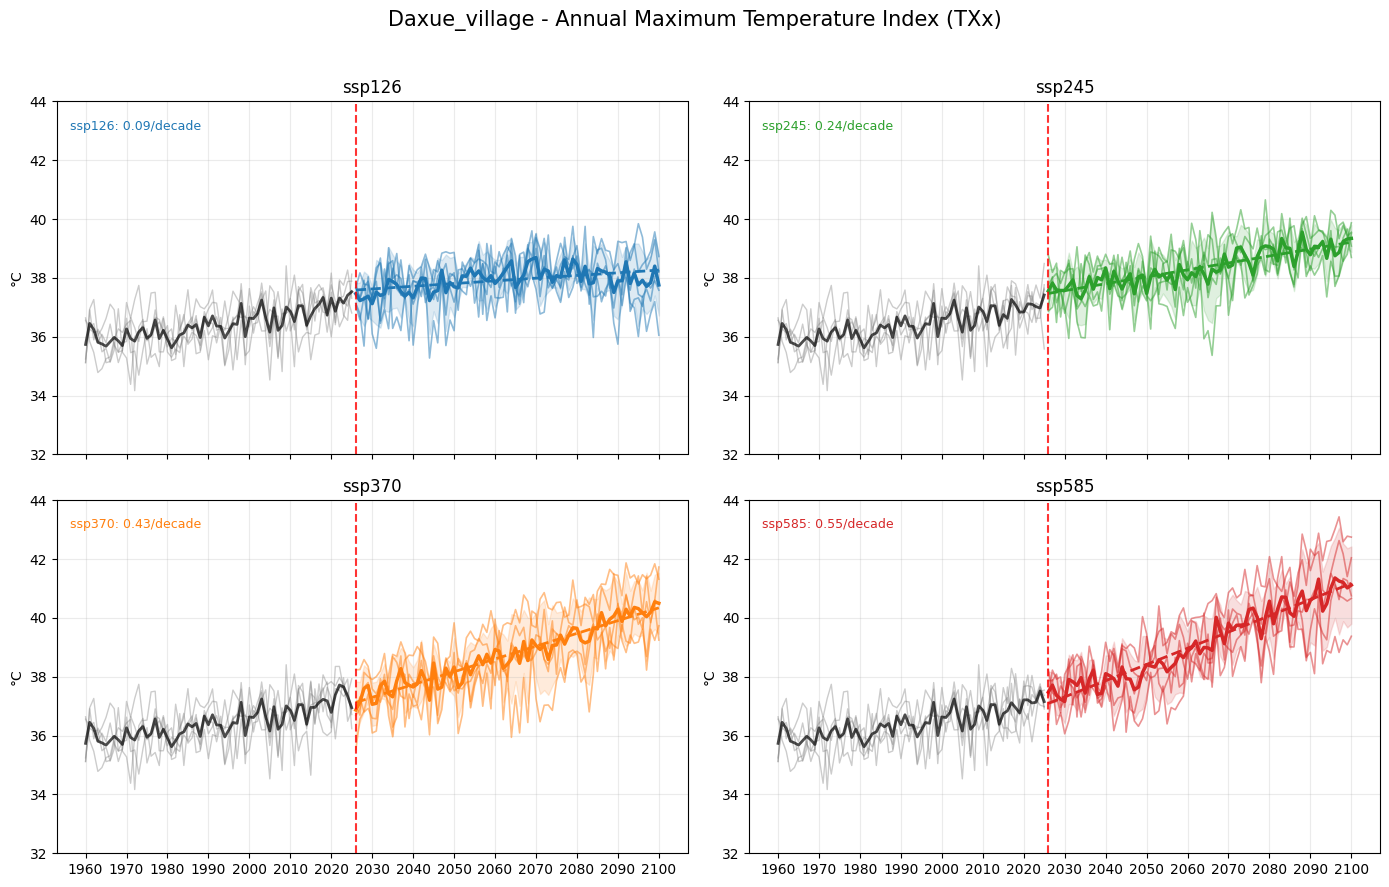

✅ Saved: /Users/stevechiao/Climate_project/程式作業/Daxue_village/figue/Daxue_village_Warm_Days.png


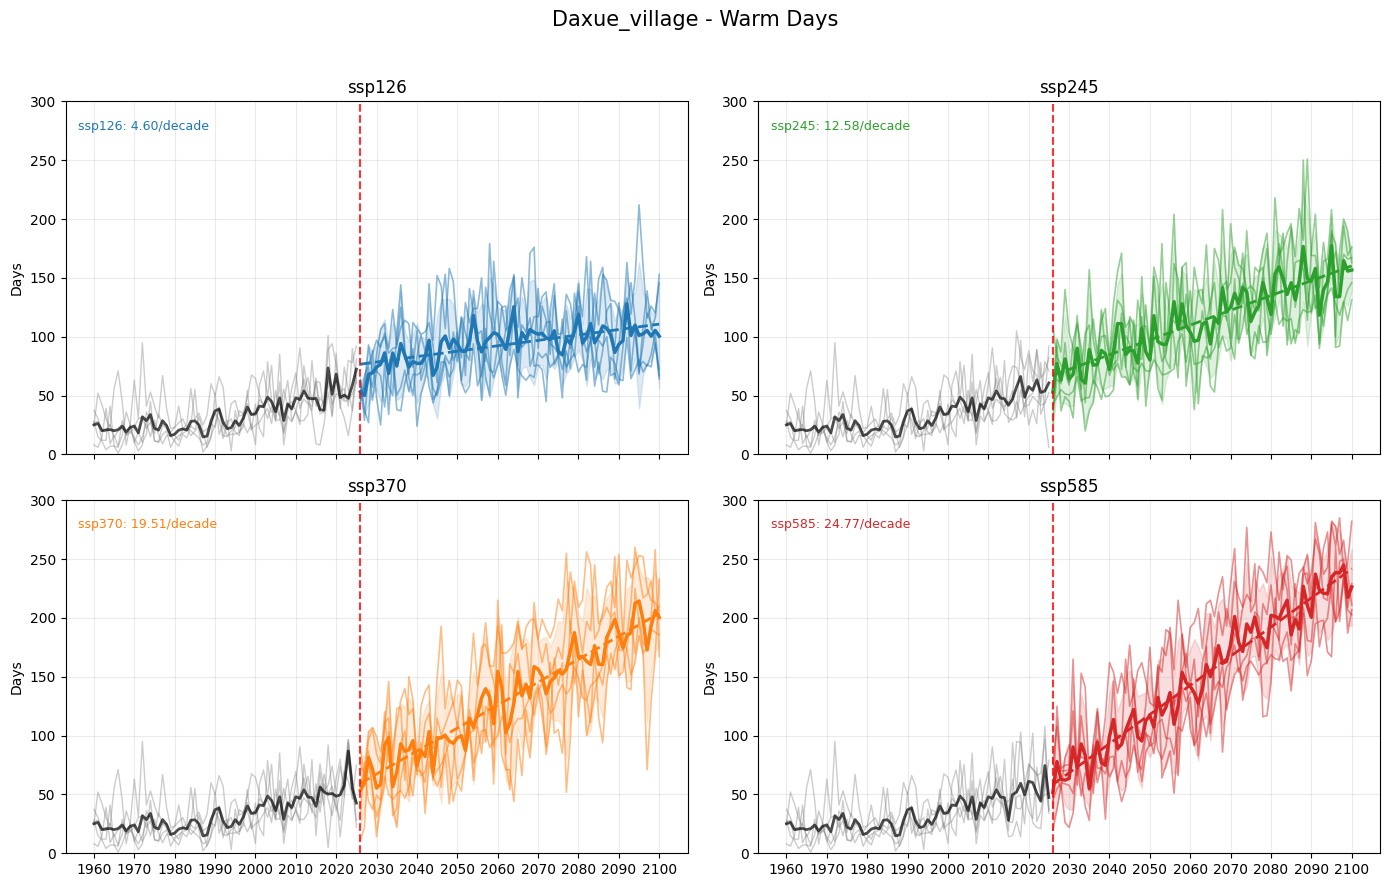

✅ Saved: /Users/stevechiao/Climate_project/程式作業/Daxue_village/figue/Daxue_village_Diurnal_Temperature_Range_DTR.png


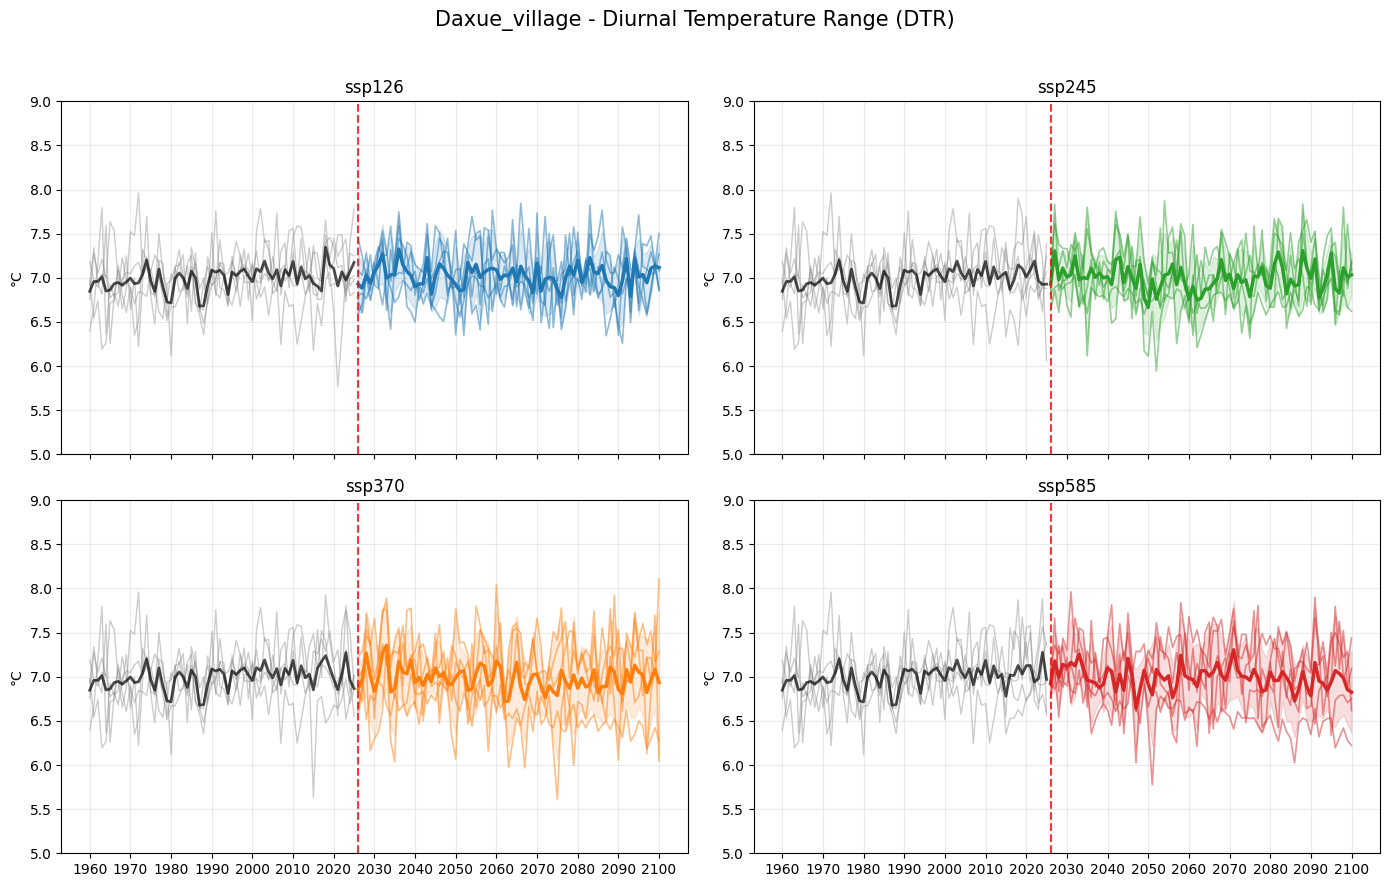

In [124]:
plot_variable_better(
    txx_result,
    var_name="TXx",
    variable_title="Annual Maximum Temperature Index (TXx)",
    ylabel="°C",
    ylim=([32,44]),
    save_dir=save_path,
    add_trend=True
)

plot_variable_better(
    warmdays_result,
    var_name="WarmDays",
    variable_title="Warm Days",
    ylabel="Days",
    ylim=plot_ylims["WarmDays"],
    save_dir=save_path,
    add_trend=True
)

plot_variable_better(
    dtr_result,
    var_name="DTR",
    variable_title="Diurnal Temperature Range (DTR)",
    ylabel="°C",
    ylim=plot_ylims["DTR"],
    save_dir=save_path,
    add_trend=False
)